In [1]:
import pandas as pd
import runpy, numpy as np, matplotlib.pyplot as plt;

%run "ArbitraryPointBField.py"

In [2]:
files = {
    "1ABZ": "MOT_Data/MOT-Data/CleanB/MOT-Bfield-1ABZ-C.csv",
    "1ABZ post": "MOT_Data/MOT-Data/CleanB/MOT-Bfield-1ABZ-post-C.csv",
    "1ABZ inverse": "MOT_Data/MOT-Data/CleanB/MOT-Bfield-1ABZinverse-C.csv",
    "1ABZ close": "MOT_Data/MOT-Data/CleanB/MOT-Bfield-1ABZClose-C.csv",
    "1ABZ top coil": "MOT_Data/MOT-Data/CleanB/MOT-Bfield-1ABZTopCoil-C.csv",
    "1ABZ bottom coil": "MOT_Data/MOT-Data/CleanB/MOT-Bfield-1ABZBottomCoil-C.csv",
    "3ABZ": "MOT_Data/MOT-Data/CleanB/MOT-Bfield-3ABZ-C.csv",
    "1ABX": "MOT_Data/MOT-Data/CleanB/MOT-Bfield-1ABX-C.csv",
}

In [3]:
# Read all files
data = {}

for name, file_path in files.items():
    df = pd.read_csv(file_path)

    # Remove accidental spaces from column names
    df.columns = df.columns.str.strip()

    data[name] = df

In [4]:
z_1ABZ = data["1ABZ"]["z(m)"]
B_1ABZ = data["1ABZ"]["B(G)"]

z_1ABZ_post = data["1ABZ post"]["z(m)"]
B_1ABZ_post = data["1ABZ post"]["B(G)"]

z_1ABZ_inverse = data["1ABZ inverse"]["z(m)"]
B_1ABZ_inverse = data["1ABZ inverse"]["B(G)"]

z_1ABZ_close = data["1ABZ close"]["z(m)"]
B_1ABZ_close = data["1ABZ close"]["B(G)"]

z_1ABZ_top = data["1ABZ top coil"]["z(m)"]
B_1ABZ_top = data["1ABZ top coil"]["B(G)"]

z_1ABZ_bottom = data["1ABZ bottom coil"]["z(m)"]
B_1ABZ_bottom = data["1ABZ bottom coil"]["B(G)"]

z_3ABZ = data["3ABZ"]["z(m)"]
B_3ABZ = data["3ABZ"]["B(G)"]

x_1ABX = data["1ABX"]["x(m)"]
B_1ABX = data["1ABX"]["B(G)"]

Gradient at center = 0.77 G/cm


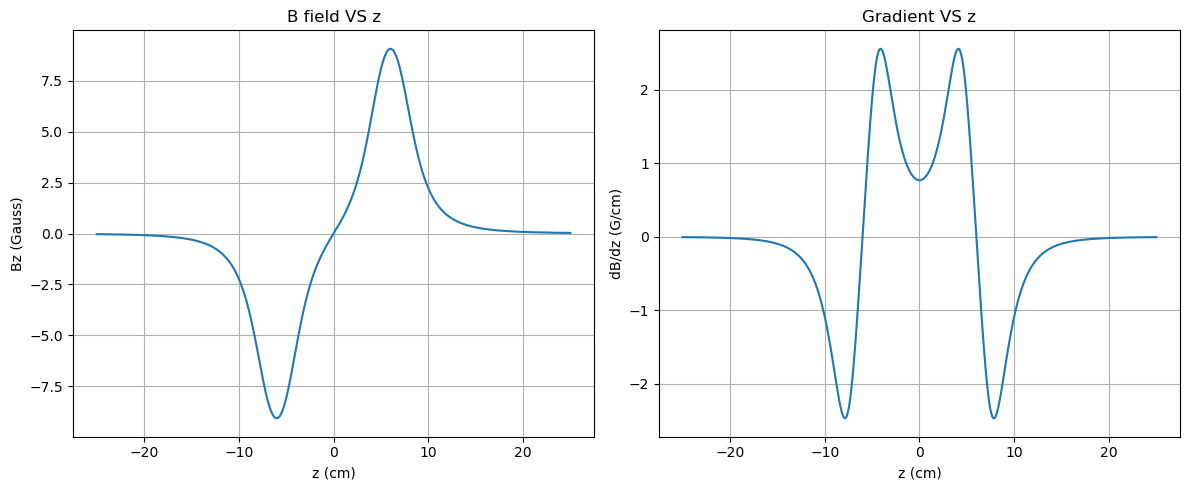

In [29]:

z_sim = np.linspace(-0.25, 0.25, 1000)   # (m)

Bz_sim = np.array([
    antiHelmholtzField(
        0,            # x position
        0,            # y position
        zi,           # z 
        0.01965,      # R (m) (1.390*0.0254)/2
        1,            # I (A)
        0.04594,      # d (m) (3.46/2+0.157/2)*0.0254
        8,            # num_layers
        6,            # num_loops
        0.001994      # Rwire (m) (0.157*0.0254)/2
    )[2]              # Select Bz from [Bx, By, Bz]
    for zi in z_sim
])


grad_z=np.gradient(Bz_sim,z_sim)/100
print(f"Gradient at center = {grad_z[np.argmin(np.abs(z_sim))]:.2f} G/cm")

fig,ax=plt.subplots(1,2,figsize=(12,5))
ax[0].plot(z_sim*100,Bz_sim)
ax[0].set(xlabel="z (cm)",ylabel="Bz (Gauss)",title="B field VS z")
ax[0].grid()
ax[1].plot(z_sim*100,grad_z) 
ax[1].set(xlabel="z (cm)",ylabel="dB/dz (G/cm)",title="Gradient VS z")
ax[1].grid()
plt.tight_layout()
plt.show()

Gradient at center = 0.77 G/cm


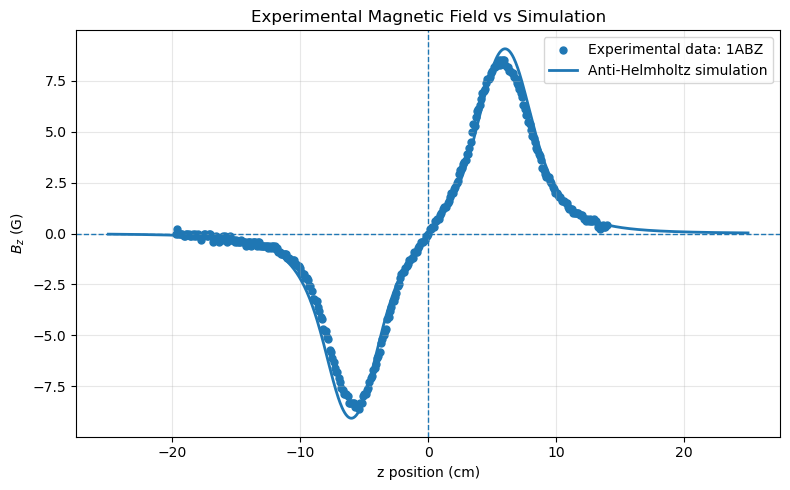

In [31]:
# Experimental data
z_1ABZ = data["1ABZ close"]["z(m)"].to_numpy()*100 #from m to cm
B_1ABZ = data["1ABZ close"]["B(G)"].to_numpy()

order = np.argsort(z_1ABZ)
z_1ABZ = z_1ABZ[order]
B_1ABZ = B_1ABZ[order]


grad_z = np.gradient(Bz_sim, z_sim)/100

center_index = np.argmin(np.abs(z_sim))

print(
    f"Gradient at center = "
    f"{grad_z[center_index]:.2f} G/cm"
)


# ============================================================
# EXPERIMENTAL DATA VS SIMULATION
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    z_1ABZ,
    B_1ABZ,
    s=25,
    label="Experimental data: 1ABZ"
)

plt.plot(
    z_sim*100,
    Bz_sim,
    linewidth=2,
    label="Anti-Helmholtz simulation"
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)

plt.xlabel("z position (cm)")
plt.ylabel(r"$B_z$ (G)")
plt.title("Experimental Magnetic Field vs Simulation")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()